# Prédiction du score d'addiction aux réseaux sociaux
## Modèle de Machine Learning - Random Forest 

dataset utilisé: Student Social Media Addiction
objectif : prédire score d'addiction (variable Addicted_score) d'un individu
Lea Carminati 09/03/2026

## 1 Importation bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') #evita non visualizzare messaggi non critici

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)


print("Bibliothèques importées avec succès")

## 2 Chargement données et aperçu

In [ ]:
df = pd.read_csv("BDD_initial\Students Social Media Addiction.csv")

print( df.shape[0], "lignes", df.shape[1], "colonnes")
print("minimum variable cible Addicted_Score:", df['Addicted_Score'].min())
print("maximum variable cible Addicted_Score:", df['Addicted_Score'].max())
df.head(10)


705 lignes 13 colonnes
minimum variable cible Addicted_Score: 2
maximum variable cible Addicted_Score: 9


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
5,6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
7,8,20,Female,Undergraduate,Brazil,5.8,Snapchat,Yes,6.0,6,In Relationship,2,8
8,9,18,Male,High School,Japan,4.0,TikTok,No,6.5,7,Single,1,5
9,10,21,Female,Graduate,South Korea,3.3,Instagram,No,7.0,7,In Relationship,1,4


Informations générales

In [ ]:
print(df.dtypes)
print(df.isnull().sum())
df.describe()

Student_ID                        int64
Age                               int64
Gender                              str
Academic_Level                      str
Country                             str
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                  str
Affects_Academic_Performance        str
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status                 str
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


## 3 Prétraitement des données

Avant d'entraîner le modèle il faut encoder les variables categorielles ( transformer de texte en nombre), supprimer les colonnes qui nous disent rien sur la prediction qu'on veut faire (non predictif) et séparer les données (cible y et features X)

le ML travail seulement avec des chiffres, donc on doit transformer les variables qualitatives en quantitatives

In [ ]:
df_ml=df.copy() #copie de travail

df_ml = df_ml.drop(columns =['Student_ID']) #inutile pour la previsione


In [ ]:
#variables à transformer de texte en nombre
categorical_cols = df_ml.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

Variables catégorielles à encoder : ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']


LabelEncoder donne un entier à chaque variable qualitative en ordre alphabetique 
exemple: Gender : Female = 0 , Male = 1

les encoder sont sauvegardés dans le dictionnaire label_encoders, qu'on va utiliser après pour les prediction

In [ ]:
#transformation variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
df_ml.head()


  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Academic_Level: {'Graduate': np.int64(0), 'High School': np.int64(1), 'Undergraduate': np.int64(2)}
  Country: {'Afghanistan': np.int64(0), 'Albania': np.int64(1), 'Andorra': np.int64(2), 'Argentina': np.int64(3), 'Armenia': np.int64(4), 'Australia': np.int64(5), 'Austria': np.int64(6), 'Azerbaijan': np.int64(7), 'Bahamas': np.int64(8), 'Bahrain': np.int64(9), 'Bangladesh': np.int64(10), 'Belarus': np.int64(11), 'Belgium': np.int64(12), 'Bhutan': np.int64(13), 'Bolivia': np.int64(14), 'Bosnia': np.int64(15), 'Brazil': np.int64(16), 'Bulgaria': np.int64(17), 'Canada': np.int64(18), 'Chile': np.int64(19), 'China': np.int64(20), 'Colombia': np.int64(21), 'Costa Rica': np.int64(22), 'Croatia': np.int64(23), 'Cyprus': np.int64(24), 'Czech Republic': np.int64(25), 'Denmark': np.int64(26), 'Ecuador': np.int64(27), 'Egypt': np.int64(28), 'Estonia': np.int64(29), 'Finland': np.int64(30), 'France': np.int64(31), 'Georgia': np.int64(32), 'G

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,6,1,3,8
1,22,1,0,39,2.1,7,0,7.5,8,2,0,3
2,20,0,2,102,6.0,6,1,5.0,5,0,4,9
3,18,1,1,101,3.0,11,0,7.0,7,2,1,4
4,21,1,0,18,4.5,0,1,6.0,6,1,2,7


## 4 séparation features / cible 
le Dataset est separé en deux parties: 80% training et 20% test (evaluer les predictions sur des données non traitées dans le training)
random_state=42 garanti toujours la même division (même à chaque répetition)


In [ ]:
X = df_ml.drop(columns=['Addicted_Score'])
y = df_ml['Addicted_Score']

print(f"Features (X) : {X.shape} → {list(X.columns)}")
print(f"Cible (y)    : {y.shape}")

# Split train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Répartition :")
print(f"  Train : {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test  : {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.0f}%)")

Features (X) : (705, 11) → ['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media']
Cible (y)    : (705,)

 Répartition :
  Train : 564 échantillons (80%)
  Test  : 141 échantillons (20%)


## 5 Modélisation - Random Forest Regression
Le Random Forest est un ensemble de nombreux arbre de decision
Chaque arbre est entraîné sur un sous ensemble **aléatoire** des donnees 
Chaque split ne considere qu'un **sous-ensemble aléatoire des features**
La prédiction finale est la moyenne des prédictions de tous les arbres
(reduit overfitting)

In [ ]:
rf_base = RandomForestRegressor(
    n_estimators=100,   # 100 arbres
    random_state=42,
    n_jobs=-1           # utilise tous les CPU
)

rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

In [ ]:
# Métriques
mae  = mean_absolute_error(y_test, y_pred_base)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2   = r2_score(y_test, y_pred_base)

print("=== Résultats — Modèle de Base ===")
print(f"  MAE  (erreur absolue moyenne) : {mae:.3f}")
print(f"  RMSE (racine erreur quadr.)   : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n Le modèle explique {r2*100:.1f}% de la variance du score")


=== Résultats — Modèle de Base ===
  MAE  (erreur absolue moyenne) : 0.078
  RMSE (racine erreur quadr.)   : 0.211
  R²   (coefficient de détermination) : 0.982

 Le modèle explique 98.2% de la variance du score


## 6 Evaluation du modèle 
**MAE** = 0.078  erreur moyen di 0.08 punti
Addicted_Score (de 2 a 9). Le modele se trompe en moyenne de 0.08 points. (si le score reéel est 7, le modèle predit entre 6.92 et 7.08)


**RMSE** = 0.211
pas de grands erreurs isolées

**R^2** = 0.982  le modèle explique le 98.2% d ela variabilité du score de dependence.


 Mental_Health_Score **transformation** directe de Addict_Score.


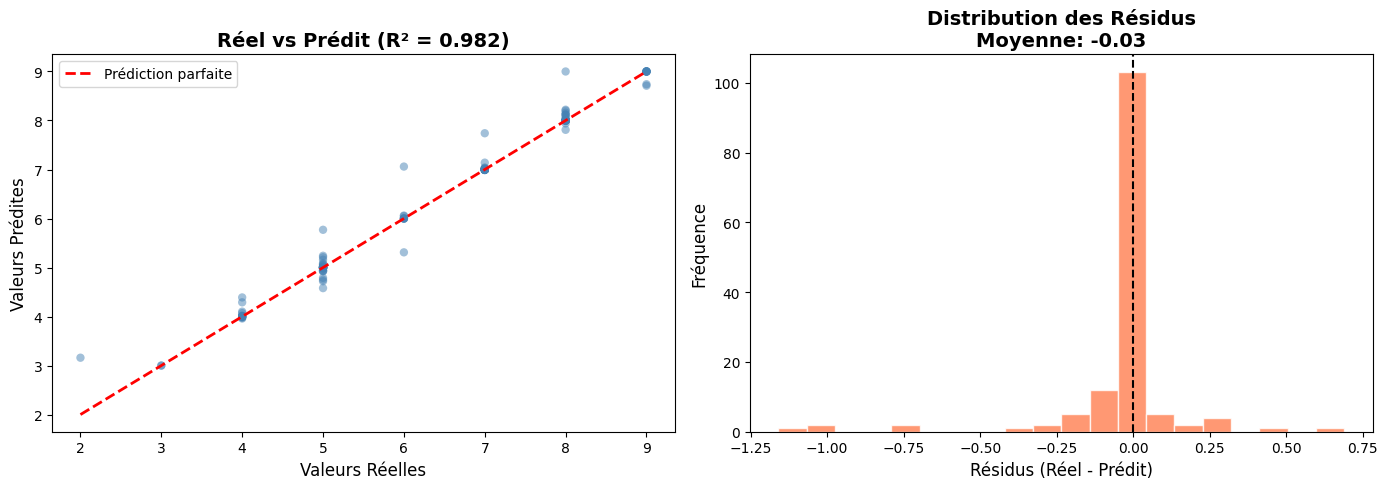

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test, y_pred_base, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles', fontsize=12)
axes[0].set_ylabel('Valeurs Prédites', fontsize=12)
axes[0].set_title(f'Réel vs Prédit (R² = {r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()

# Distribution des Résidus
residuals = y_test - y_pred_base
axes[1].hist(residuals, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.2f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Scatter plot "réel vs prédit"on voit que allinées présque parfaitement


histogramme des residus ( somme autour de 0) se balancent.

Le dataset est divisée en 5 blocs. Le modele vient entraîné 5 fois, chaque fois en utilisant 4 blocs pour le training et 1 pour le test

In [ ]:
# Validation croisée (5-fold)
cv_scores = cross_val_score(rf_base, X, y, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R^2 moyen  : {cv_scores.mean():.4f}")
print(f"  Écart-type : {cv_scores.std():.4f}")


=== Validation Croisée (5-fold) ===
  Fold 1: R² = 0.9174
  Fold 2: R² = 0.9222
  Fold 3: R² = 0.9945
  Fold 4: R² = 0.9912
  Fold 5: R² = 0.9639

  R^2 moyen  : 0.9578
  Écart-type : 0.0329


Ces résultats montrent que le moele marche bien sur une portion quelconque du dataset et non seulment sur la partie de train/test. Montre que la valeur R^2 = 0.9 obtenu avant bien valide (pas du au hasard)


std < 0.05 modele stable et generalise bien

## 7 Importance des features

Random Forest calcule de façon automatique le poids de chaque variable dans les previsions

In [ ]:
importances = rf_base.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]


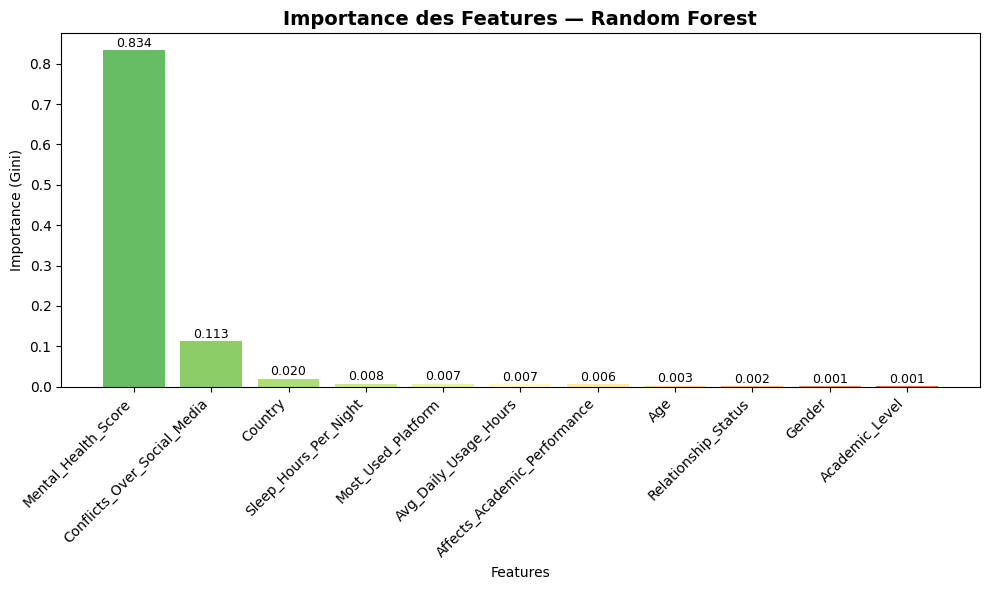


 Top 5 features les plus importantes :
  1. Mental_Health_Score (83.4%)
  2. Conflicts_Over_Social_Media (11.3%)
  3. Country (2.0%)
  4. Sleep_Hours_Per_Night (0.8%)
  5. Most_Used_Platform (0.7%)


In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_names)))
bars = plt.bar(range(len(feature_names)),
               importances[indices],
               color=colors[np.argsort(np.argsort(importances[indices]))])
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Importance des Features — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Importance (Gini)')
plt.xlabel('Features')

for bar, imp in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
             f'{imp:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n Top 5 features les plus importantes :")
for i in range(5):
    print(f"  {i+1}. {feature_names[indices[i]]} ({importances[indices[i]]*100:.1f}%)")

Ici on remarque que Mental_Health_Score domnia quasi tutto : cel asubgere une correlation très forte entre addiction aux reseaux sociaux et santé mentale


Cela on le retouve dans le notebook de visualisation

## 8 Optimisation des Hyperparametres (GridSearchCV)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n=== Meilleurs Hyperparamètres ===")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n  R² (validation) : {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Meilleurs Hyperparamètres ===
  max_depth: None
  max_features: sqrt
  min_samples_split: 2
  n_estimators: 200

  R² (validation) : 0.9827


In [ ]:
# Évaluation du meilleur modèle
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print("=== Comparaison : Modèle de Base vs Optimisé ===")
print(f"{'Métrique':<10} {'Base':>10} {'Optimisé':>10} {'Δ':>10}")
print("-" * 42)
print(f"{'MAE':<10} {mae:>10.3f} {mae_best:>10.3f} {mae_best-mae:>+10.3f}")
print(f"{'RMSE':<10} {rmse:>10.3f} {rmse_best:>10.3f} {rmse_best-rmse:>+10.3f}")
print(f"{'R²':<10} {r2:>10.3f} {r2_best:>10.3f} {r2_best-r2:>+10.3f}")


=== Comparaison : Modèle de Base vs Optimisé ===
Métrique         Base   Optimisé          Δ
------------------------------------------
MAE             0.078      0.095     +0.017
RMSE            0.211      0.193     -0.018
R²              0.982      0.985     +0.003


## 9 Exemple de Prédiction sur un nouvel étudiant

In [ ]:
# Exemple : étudiant de 20 ans, Female, Undergraduate, 6h/jour sur Instagram
new_student = pd.DataFrame({
    'Age': [20],
    'Gender': [label_encoders['Gender'].transform(['Female'])[0]],
    'Academic_Level': [label_encoders['Academic_Level'].transform(['Undergraduate'])[0]],
    'Country': [label_encoders['Country'].transform(['France'])[0]
                if 'France' in label_encoders['Country'].classes_
                else label_encoders['Country'].transform([label_encoders['Country'].classes_[0]])[0]],
    'Avg_Daily_Usage_Hours': [6.0],
    'Most_Used_Platform': [label_encoders['Most_Used_Platform'].transform(['Instagram'])[0]],
    'Affects_Academic_Performance': [label_encoders['Affects_Academic_Performance'].transform(['Yes'])[0]],
    'Sleep_Hours_Per_Night': [5.5],
    'Mental_Health_Score': [5],
    'Relationship_Status': [label_encoders['Relationship_Status'].transform(['Single'])[0]],
    'Conflicts_Over_Social_Media': [3]
})

prediction = best_rf.predict(new_student)[0]
print(f"Profil de l'étudiant :")
print(f"   Age: 20 ans | Genre: Female | Niveau: Undergraduate")
print(f"   Utilisation: 6h/jour | Plateforme: Instagram")
print(f"   Heures de sommeil: 5.5 | Score santé mentale: 5/10")
print(f"   Conflits liés aux réseaux: 3")
print(f"\nScore d'addiction prédit : {prediction:.1f} / 10")
print(f"   Niveau : {'Élevé' if prediction >= 7 else 'Moyen' if prediction >= 4 else 'Faible'}")


Profil de l'étudiant :
   Age: 20 ans | Genre: Female | Niveau: Undergraduate
   Utilisation: 6h/jour | Plateforme: Instagram
   Heures de sommeil: 5.5 | Score santé mentale: 5/10
   Conflits liés aux réseaux: 3

Score d'addiction prédit : 7.5 / 10
   Niveau : Élevé


In [ ]:
# Exemple : étudiant de 17 ans, Male, High School, 4h/jour sur TikTok
new_student_2 = pd.DataFrame({
    'Age': [17],
    'Gender': [label_encoders['Gender'].transform(['Male'])[0]],
    'Academic_Level': [label_encoders['Academic_Level'].transform(['High School'])[0]],
    'Country': [label_encoders['Country'].transform(['France'])[0]
                if 'France' in label_encoders['Country'].classes_
                else label_encoders['Country'].transform([label_encoders['Country'].classes_[0]])[0]],
    'Avg_Daily_Usage_Hours': [4.0],
    'Most_Used_Platform': [label_encoders['Most_Used_Platform'].transform(['TikTok'])[0]],
    'Affects_Academic_Performance': [label_encoders['Affects_Academic_Performance'].transform(['No'])[0]],
    'Sleep_Hours_Per_Night': [7.5],
    'Mental_Health_Score': [8],
    'Relationship_Status': [label_encoders['Relationship_Status'].transform(['Single'])[0]],
    'Conflicts_Over_Social_Media': [1]
})

prediction_2 = best_rf.predict(new_student_2)[0]
print(f"Profil de l'étudiant :")
print(f"   Age: 17 ans | Genre: Male | Niveau: High School")
print(f"   Utilisation: 4h/jour | Plateforme: TikTok")
print(f"   Heures de sommeil: 7.5 | Score santé mentale: 8/10")
print(f"   Conflits liés aux réseaux: 1")
print(f"\nScore d'addiction prédit : {prediction_2:.1f} / 10")
print(f"   Niveau : {'Élevé' if prediction_2 >= 7 else 'Moyen' if prediction_2 >= 4 else 'Faible'}")

Profil de l'étudiant :
   Age: 17 ans | Genre: Male | Niveau: High School
   Utilisation: 4h/jour | Plateforme: TikTok
   Heures de sommeil: 7.5 | Score santé mentale: 8/10
   Conflits liés aux réseaux: 1

Score d'addiction prédit : 3.9 / 10
   Niveau : Faible
